# Neurons and Layers — Regression & Classification with a Single Neuron

This notebook is my own reworked version of a lab from the *Advanced Learning Algorithms* course (Machine Learning Specialization, DeepLearning.AI / Coursera). The original lab used a house-price dataset for the regression neuron and a small toy dataset for the classification neuron.

Here I've rebuilt it end-to-end with **completely different datasets** — study hours vs. exam scores, and hours of sleep vs. alertness — while keeping the same underlying concept: showing that a single TensorFlow/Keras neuron implements exactly the same math as the linear regression and logistic regression models from Course 1.

This version is fully self-contained (no external course utility files needed) so it can run anywhere — Colab, local Jupyter, or straight from GitHub.

**Goals of this notebook:**
- Build a single neuron with no activation and show it reproduces linear regression
- Build a single neuron with a sigmoid activation and show it reproduces logistic regression
- Manually set neuron weights and verify the neuron's output matches the math by hand

## Packages

We're using TensorFlow/Keras for the neuron implementations, NumPy for the manual math, and Matplotlib for plotting. No custom lab utility files are required — all plotting helpers are defined in this notebook.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras import Sequential

import logging
logging.getLogger("tensorflow").setLevel(logging.ERROR)
tf.autograph.set_verbosity(0)

plt.style.use('seaborn-v0_8-whitegrid')
np.set_printoptions(precision=4)

I0000 00:00:1786821637.465814     541 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1786821637.649733     541 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1786821640.214116     541 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


## Helper functions

Small self-written plotting/utility functions (replacing the course's `lab_utils_common` / `lab_neurons_utils`).

In [2]:
def sigmoidnp(z):
    """Numerically stable sigmoid, computed with plain NumPy."""
    return 1 / (1 + np.exp(-z))


def plt_linear(X_train, Y_train, prediction_tf, prediction_np):
    """Compare the TensorFlow neuron's linear predictions to a hand-computed NumPy version."""
    fig, ax = plt.subplots(1, 1, figsize=(6, 4))
    ax.scatter(X_train, Y_train, marker='x', c='red', s=90, label="Actual data", zorder=3)
    ax.plot(X_train, prediction_tf, c='steelblue', lw=2, label="TensorFlow neuron output")
    ax.scatter(X_train, prediction_np, c='orange', marker='o', s=60,
               label="NumPy (w·x + b) output", zorder=3)
    ax.set_title("Single Neuron (no activation) vs. Manual Linear Regression")
    ax.set_xlabel("Hours studied")
    ax.set_ylabel("Exam score")
    ax.legend()
    plt.show()


def plt_logistic(X_train, Y_train, model, set_w, set_b, pos, neg):
    """Plot the data plus the sigmoid neuron's output curve and decision boundary."""
    x_fine = np.linspace(X_train.min() - 1, X_train.max() + 1, 200).reshape(-1, 1)
    y_fine = model.predict(x_fine, verbose=0)

    fig, ax = plt.subplots(1, 1, figsize=(6, 4))
    ax.plot(x_fine, y_fine, c='steelblue', lw=2, label="Sigmoid neuron output")
    ax.scatter(X_train[pos], Y_train[pos], marker='x', s=90, c='red', label="Alert (y=1)", zorder=3)
    ax.scatter(X_train[neg], Y_train[neg], marker='o', s=90, facecolors='none',
               edgecolors='steelblue', linewidths=2, label="Drowsy (y=0)", zorder=3)

    boundary_x = -set_b[0] / set_w[0, 0]
    ax.axvline(boundary_x, color='gray', linestyle='--', lw=1.5,
               label=f"Decision boundary (x={boundary_x:.2f})")

    ax.set_ylim(-0.08, 1.1)
    ax.set_xlabel("Hours of sleep")
    ax.set_ylabel("P(alert)")
    ax.set_title("Single Neuron (sigmoid) vs. Manual Logistic Regression")
    ax.legend(loc="center left")
    plt.show()

## Part 1 — Neuron without activation (Regression / Linear Model)

The function implemented by a neuron with no activation is the same as linear regression:

$$ f_{w,b}(x^{(i)}) = w \cdot x^{(i)} + b $$

### Dataset

Instead of house size vs. price, I'm using **hours studied vs. exam score** for two students.

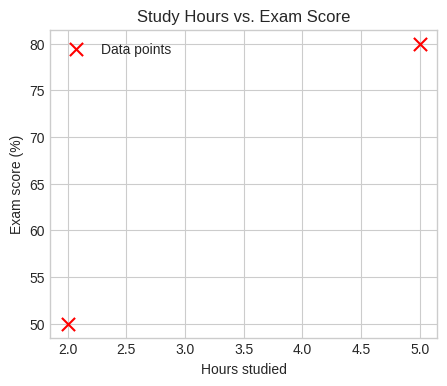

In [3]:
X_train = np.array([[2.0], [5.0]], dtype=np.float32)   # hours studied
Y_train = np.array([[50.0], [80.0]], dtype=np.float32)  # exam score (%)

fig, ax = plt.subplots(1, 1, figsize=(5, 4))
ax.scatter(X_train, Y_train, marker='x', c='red', s=90, label="Data points")
ax.legend()
ax.set_ylabel('Exam score (%)')
ax.set_xlabel('Hours studied')
ax.set_title('Study Hours vs. Exam Score')
plt.show()

We can define a layer with a single neuron (unit) and compare it against the familiar linear regression function.

In [4]:
linear_layer = tf.keras.layers.Dense(units=1, activation='linear')

Let's check the weights before the layer has seen any data — they won't exist yet.

In [5]:
linear_layer.get_weights()

[]

The weights aren't instantiated until the layer is called on some input. Let's run one example through it (the input to a Dense layer must be 2-D, so we reshape it).

In [6]:
a1 = linear_layer(X_train[0].reshape(1, 1))
print(a1)

tf.Tensor([[1.8974]], shape=(1, 1), dtype=float32)


Now let's look at the randomly-initialized weight and bias.

In [7]:
w, b = linear_layer.get_weights()
print(f"w = {w}, b = {b}")

w = [[0.9487]], b = [0.]


A one-feature linear regression model has exactly one weight and one bias — matching our `linear_layer`.

Instead of random values, let's set them to values we've worked out by hand for this dataset: the line through (2, 50) and (5, 80) has slope **w = 10** and intercept **b = 30**.

In [8]:
set_w = np.array([[10]])
set_b = np.array([30])

# set_weights takes a list of numpy arrays: [weights, bias]
linear_layer.set_weights([set_w, set_b])
print(linear_layer.get_weights())

[array([[10.]], dtype=float32), array([30.], dtype=float32)]


Now let's compare the neuron's output to the same computation done manually with NumPy.

In [9]:
a1 = linear_layer(X_train[0].reshape(1, 1))
print("TensorFlow neuron:", a1.numpy())

alin = np.dot(set_w, X_train[0].reshape(1, 1)) + set_b
print("NumPy w·x + b:    ", alin)

TensorFlow neuron: [[50.]]
NumPy w·x + b:     [[50.]]


They match. Now let's run the neuron over the full training set and plot it against the manual calculation.

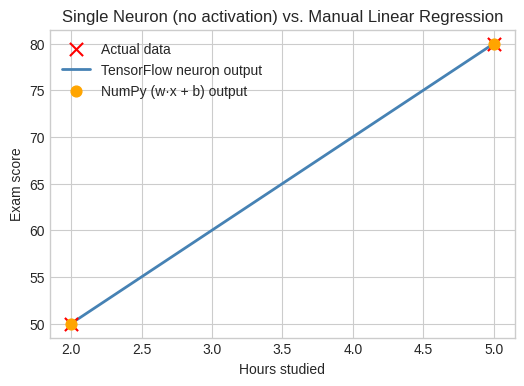

In [10]:
prediction_tf = linear_layer(X_train)
prediction_np = np.dot(X_train, set_w) + set_b

plt_linear(X_train, Y_train, prediction_tf, prediction_np)

## Part 2 — Neuron with Sigmoid activation (Logistic Model)

A neuron with a sigmoid activation implements logistic regression:

$$ f_{w,b}(x^{(i)}) = g(w x^{(i)} + b), \qquad g(x) = \text{sigmoid}(x) $$

### Dataset

Instead of the course's generic 0–5 toy example, I'm using **hours of sleep vs. whether a person tests as alert (1) or drowsy (0)** the next morning.

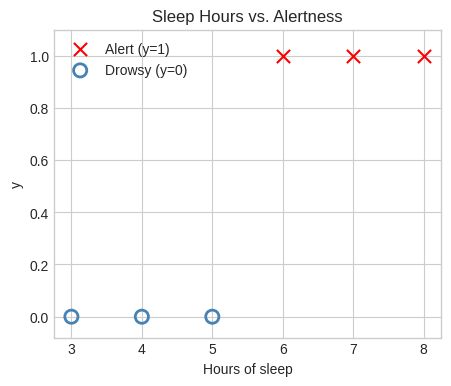

In [11]:
X_train = np.array([3, 4, 5, 6, 7, 8], dtype=np.float32).reshape(-1, 1)  # hours of sleep
Y_train = np.array([0, 0, 0, 1, 1, 1], dtype=np.float32).reshape(-1, 1)  # 1 = alert, 0 = drowsy

pos = Y_train == 1
neg = Y_train == 0

fig, ax = plt.subplots(1, 1, figsize=(5, 4))
ax.scatter(X_train[pos], Y_train[pos], marker='x', s=90, c='red', label="Alert (y=1)")
ax.scatter(X_train[neg], Y_train[neg], marker='o', s=90, facecolors='none',
           edgecolors='steelblue', linewidths=2, label="Drowsy (y=0)")
ax.set_ylim(-0.08, 1.1)
ax.set_ylabel('y')
ax.set_xlabel('Hours of sleep')
ax.set_title('Sleep Hours vs. Alertness')
ax.legend()
plt.show()

### Logistic neuron

We build a single-neuron `Sequential` model with a sigmoid activation — this is the standard way to build multi-layer models in Keras, even though here we only have one layer with one unit.

In [12]:
model = Sequential([
    tf.keras.layers.Dense(1, input_dim=1, activation='sigmoid', name='L1')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


`model.summary()` shows the layers and parameter count. One layer, one unit, two parameters (w and b).

In [13]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ L1 (Dense)                      │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2 (8.00 B)

 Trainable params: 2 (8.00 B)

 Non-trainable params: 0 (0.00 B)

In [14]:
logistic_layer = model.get_layer('L1')
w, b = logistic_layer.get_weights()
print(w, b)
print(w.shape, b.shape)

[[0.9347]] [0.]
(1, 1) (1,)


Let's set the weight and bias to known values by hand. Looking at the data, alertness flips from 0 to 1 somewhere between 5 and 6 hours of sleep, so we want a decision boundary around **x = 5.5**. Using **w = 2, b = -11** puts the boundary exactly there (since the boundary is where w·x + b = 0, i.e. x = 11/2 = 5.5).

In [15]:
set_w = np.array([[2]])
set_b = np.array([-11])
logistic_layer.set_weights([set_w, set_b])
print(logistic_layer.get_weights())

[array([[2.]], dtype=float32), array([-11.], dtype=float32)]


Let's compare the neuron's output to the same computation done manually with NumPy + our own sigmoid function.

In [16]:
a1 = model.predict(X_train[0].reshape(1, 1), verbose=0)
print("TensorFlow neuron:", a1)

alog = sigmoidnp(np.dot(set_w, X_train[0].reshape(1, 1)) + set_b)
print("NumPy sigmoid:    ", alog)

TensorFlow neuron: [[0.0067]]
NumPy sigmoid:     [[0.0067]]


They match. Now let's plot the sigmoid curve, the decision boundary, and how the data falls on either side.

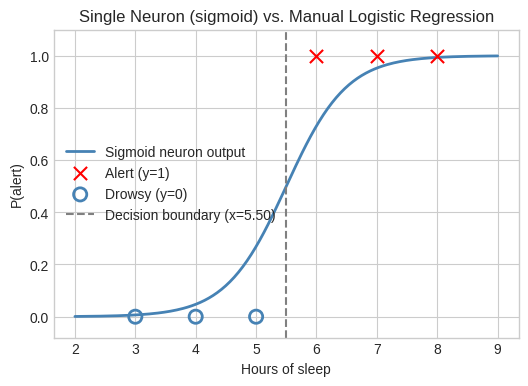

In [17]:
plt_logistic(X_train, Y_train, model, set_w, set_b, pos, neg)

The shading of the curve reflects the neuron's output — the probability of being "alert" — smoothly moving from 0 to 1 as sleep hours increase, crossing 0.5 right at the decision boundary.

## What I learned

- A Keras `Dense` layer with `activation='linear'` and a single unit is mathematically identical to linear regression — it's literally computing `w·x + b`.
- A `Dense` layer with `activation='sigmoid'` is mathematically identical to logistic regression — `sigmoid(w·x + b)`.
- Layer weights aren't created until the layer actually sees an input (they're built lazily based on input shape).
- `set_weights()` lets you manually inject known parameters into a layer, which is a great way to sanity-check that a layer is doing the math you think it's doing.
- This is the conceptual bridge between the regression/classification models from Course 1 and how neural networks are built layer-by-layer with Keras.

*Original lab: "Neurons and Layers" — Machine Learning Specialization (DeepLearning.AI / Coursera). Dataset and explanations reworked by me for practice.*